In [7]:
# 02 Baselines
# This notebook establishes baseline performance for the rice leaf disease classification task using a simple machine learning model and a small CNN trained from scratch. These models serve as reference points for comparison with the EfficientNetB0-based approach.

In [8]:
# =========================
# CELL 1: IMPORTS
# =========================
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras import layers, models

from src.data_pipeline import load_dataframes, encode_labels, make_datasets

In [9]:
# =========================
# CELL 2: LOAD DATA
# =========================
import os

train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")

train_df["full_path"] = train_df["filepath"].apply(lambda p: os.path.normpath(os.path.join("..", p)))
val_df["full_path"] = val_df["filepath"].apply(lambda p: os.path.normpath(os.path.join("..", p)))

train_df = train_df[train_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["full_path"].apply(os.path.exists)].reset_index(drop=True)

y_train, y_val, label_encoder, class_names = encode_labels(train_df, val_df)

print("Classes:", class_names)
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print(train_df["full_path"].apply(os.path.exists).value_counts())
print(val_df["full_path"].apply(os.path.exists).value_counts())

train_df.head()

Classes: ['BrownSpot' 'Healthy' 'leaf_blast' 'rice_hispa']
Train shape: (4106, 4)
Val shape: (1027, 4)
full_path
True    4106
Name: count, dtype: int64
full_path
True    1027
Name: count, dtype: int64


,filepath,label,split,full_path
0,data/processed/train/BrownSpot/brown_spot434.jpg,BrownSpot,train,..\data\processed\train\BrownSpot\brown_spot43...
1,data/processed/train/leaf_blast/leaf_blast777.jpg,leaf_blast,train,..\data\processed\train\leaf_blast\leaf_blast7...
2,data/processed/train/rice_hispa/rice_hispa919.jpg,rice_hispa,train,..\data\processed\train\rice_hispa\rice_hispa9...
3,data/processed/train/rice_hispa/rice_hispa291.jpg,rice_hispa,train,..\data\processed\train\rice_hispa\rice_hispa2...
4,data/processed/train/BrownSpot/brown_spot90.jpg,BrownSpot,train,..\data\processed\train\BrownSpot\brown_spot90...


In [10]:
# =========================
# CELL 3: SIMPLE IMAGE FEATURE EXTRACTOR
# =========================
IMG_SIZE_BASELINE = (64, 64)

def load_flattened_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE_BASELINE)
    img = tf.cast(img, tf.float32) / 255.0
    return tf.reshape(img, [-1]).numpy()

X_train_flat = np.array([load_flattened_image(p) for p in train_df["full_path"] if os.path.exists(p)])
X_val_flat = np.array([load_flattened_image(p) for p in val_df["full_path"] if os.path.exists(p)])

print("Flattened train shape:", X_train_flat.shape)
print("Flattened val shape:", X_val_flat.shape)

Flattened train shape: (4106, 12288)
Flattened val shape: (1027, 12288)


In [11]:
# =========================
# CELL 4: PCA FOR FASTER LOGISTIC REGRESSION
# =========================
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_val_pca = pca.transform(X_val_flat)

print("PCA train shape:", X_train_pca.shape)
print("PCA val shape:", X_val_pca.shape)

PCA train shape: (4106, 100)
PCA val shape: (1027, 100)


In [12]:
# =========================
# CELL 5: LOGISTIC REGRESSION BASELINE
# =========================
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_pca, y_train)

lr_pred = lr_model.predict(X_val_pca)

lr_acc = accuracy_score(y_val, lr_pred)
lr_f1 = f1_score(y_val, lr_pred, average="macro")

print("Logistic Regression Accuracy:", round(lr_acc, 4))
print("Logistic Regression Macro-F1:", round(lr_f1, 4))
print(classification_report(y_val, lr_pred, target_names=class_names))

Logistic Regression Accuracy: 0.7089
Logistic Regression Macro-F1: 0.6624
              precision    recall  f1-score   support

   BrownSpot       0.71      0.68      0.70       296
     Healthy       0.52      0.41      0.46        78
  leaf_blast       0.66      0.64      0.65       361
  rice_hispa       0.79      0.90      0.84       292

    accuracy                           0.71      1027
   macro avg       0.67      0.66      0.66      1027
weighted avg       0.70      0.71      0.70      1027



In [13]:
# =========================
# CELL 6: DATASETS FOR SIMPLE CNN
# =========================
IMG_SIZE_CNN = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image_baseline(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE_CNN)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_df["full_path"].values, y_train))
    .shuffle(len(train_df), seed=42, reshuffle_each_iteration=True)
    .map(load_image_baseline, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_df["full_path"].values, y_val))
    .map(load_image_baseline, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [14]:
# =========================
# CELL 7: SIMPLE CNN FROM SCRATCH
# =========================
simple_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

simple_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

simple_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,764 (366.27 KB)

 Trainable params: 93,764 (366.27 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# =========================
# CELL 8: TRAIN SIMPLE CNN
# =========================
simple_history = simple_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - accuracy: 0.5546 - loss: 1.0172 - val_accuracy: 0.5560 - val_loss: 0.9872
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 32s 247ms/step - accuracy: 0.6812 - loss: 0.8243 - val_accuracy: 0.7118 - val_loss: 0.7498
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 31s 240ms/step - accuracy: 0.7029 - loss: 0.7621 - val_accuracy: 0.7137 - val_loss: 0.7059
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 253ms/step - accuracy: 0.6980 - loss: 0.7417 - val_accuracy: 0.6719 - val_loss: 0.7803
Epoch 5/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 30s 233ms/step - accuracy: 0.7189 - loss: 0.7059 - val_accuracy: 0.7205 - val_loss: 0.6626


In [16]:
# =========================
# CELL 9: EVALUATE SIMPLE CNN
# =========================
simple_probs = simple_cnn.predict(val_ds, verbose=1)
simple_pred = np.argmax(simple_probs, axis=1)

simple_acc = accuracy_score(y_val, simple_pred)
simple_f1 = f1_score(y_val, simple_pred, average="macro")

print("Simple CNN Accuracy:", round(simple_acc, 4))
print("Simple CNN Macro-F1:", round(simple_f1, 4))
print(classification_report(y_val, simple_pred, target_names=class_names))

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step
Simple CNN Accuracy: 0.7205
Simple CNN Macro-F1: 0.5779
              precision    recall  f1-score   support

   BrownSpot       0.69      0.73      0.71       296
     Healthy       0.67      0.03      0.05        78
  leaf_blast       0.64      0.69      0.66       361
  rice_hispa       0.85      0.93      0.89       292

    accuracy                           0.72      1027
   macro avg       0.71      0.60      0.58      1027
weighted avg       0.72      0.72      0.69      1027



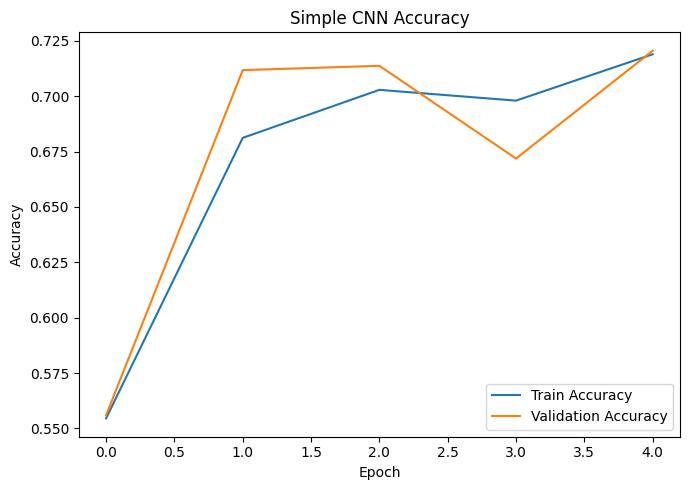

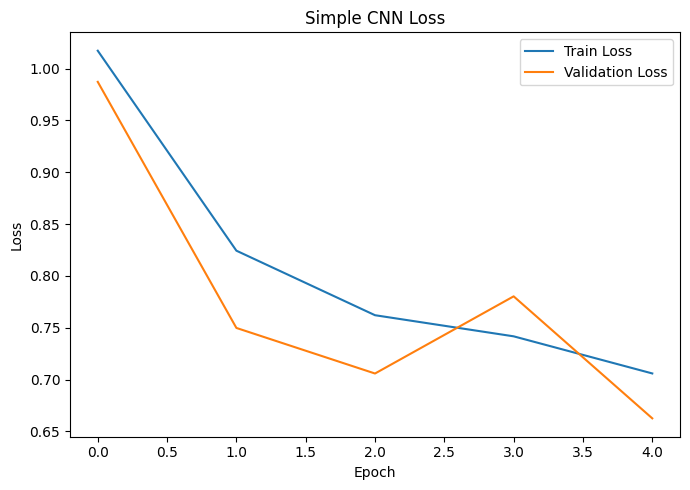

In [17]:
# =========================
# CELL 10: SIMPLE CNN LEARNING CURVES
# =========================
plt.figure(figsize=(7, 5))
plt.plot(simple_history.history["accuracy"], label="Train Accuracy")
plt.plot(simple_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Simple CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(simple_history.history["loss"], label="Train Loss")
plt.plot(simple_history.history["val_loss"], label="Validation Loss")
plt.title("Simple CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# =========================
# CELL 11: BASELINE COMPARISON TABLE
# =========================
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Simple CNN"],
    "Accuracy": [lr_acc, simple_acc],
    "Macro-F1": [lr_f1, simple_f1]
})

baseline_results

,Model,Accuracy,Macro-F1
0,Logistic Regression,0.708861,0.662381
1,Simple CNN,0.720545,0.577858
